# モーメント編集データで学習したConvNext V2に対するLLC

In [1]:
import json
from pathlib import Path

CALIB_PATH = Path(
    "/home/nakano/server/calibration_results_deletion_vision/"
    "calib_convnext-atto_deletion_conrad_step100000.json"
)

with open(CALIB_PATH) as f:
    data = json.load(f)

records = sorted(data["records"], key=lambda r: r["epsilon"])
print(f"{len(records)} records found")
for r in records:
    print(f"  epsilon={r['epsilon']:.1e}  gamma={r['gamma']}  "
          f"accept={r['mean_accept_prob_full']:.3f}  "
          f"flat={r['flatness_score_last10pct']:.5f}")

14 records found
  epsilon=1.0e-10  gamma=1.0  accept=0.583  flat=0.00169
  epsilon=1.0e-09  gamma=1.0  accept=0.581  flat=0.00233
  epsilon=3.0e-09  gamma=1.0  accept=0.584  flat=0.00233
  epsilon=1.0e-08  gamma=1.0  accept=0.578  flat=0.00148
  epsilon=3.0e-08  gamma=1.0  accept=0.568  flat=0.00330
  epsilon=1.0e-07  gamma=1.0  accept=0.543  flat=0.00207
  epsilon=1.2e-07  gamma=1.0  accept=0.534  flat=0.00235
  epsilon=1.5e-07  gamma=1.0  accept=0.527  flat=0.00291
  epsilon=1.8e-07  gamma=1.0  accept=0.515  flat=0.00353
  epsilon=2.0e-07  gamma=1.0  accept=0.506  flat=0.00395
  epsilon=2.3e-07  gamma=1.0  accept=0.488  flat=0.00471
  epsilon=2.6e-07  gamma=1.0  accept=0.490  flat=-0.00097
  epsilon=3.0e-07  gamma=1.0  accept=0.509  flat=-0.00133
  epsilon=1.0e-06  gamma=1.0  accept=0.464  flat=-0.00237


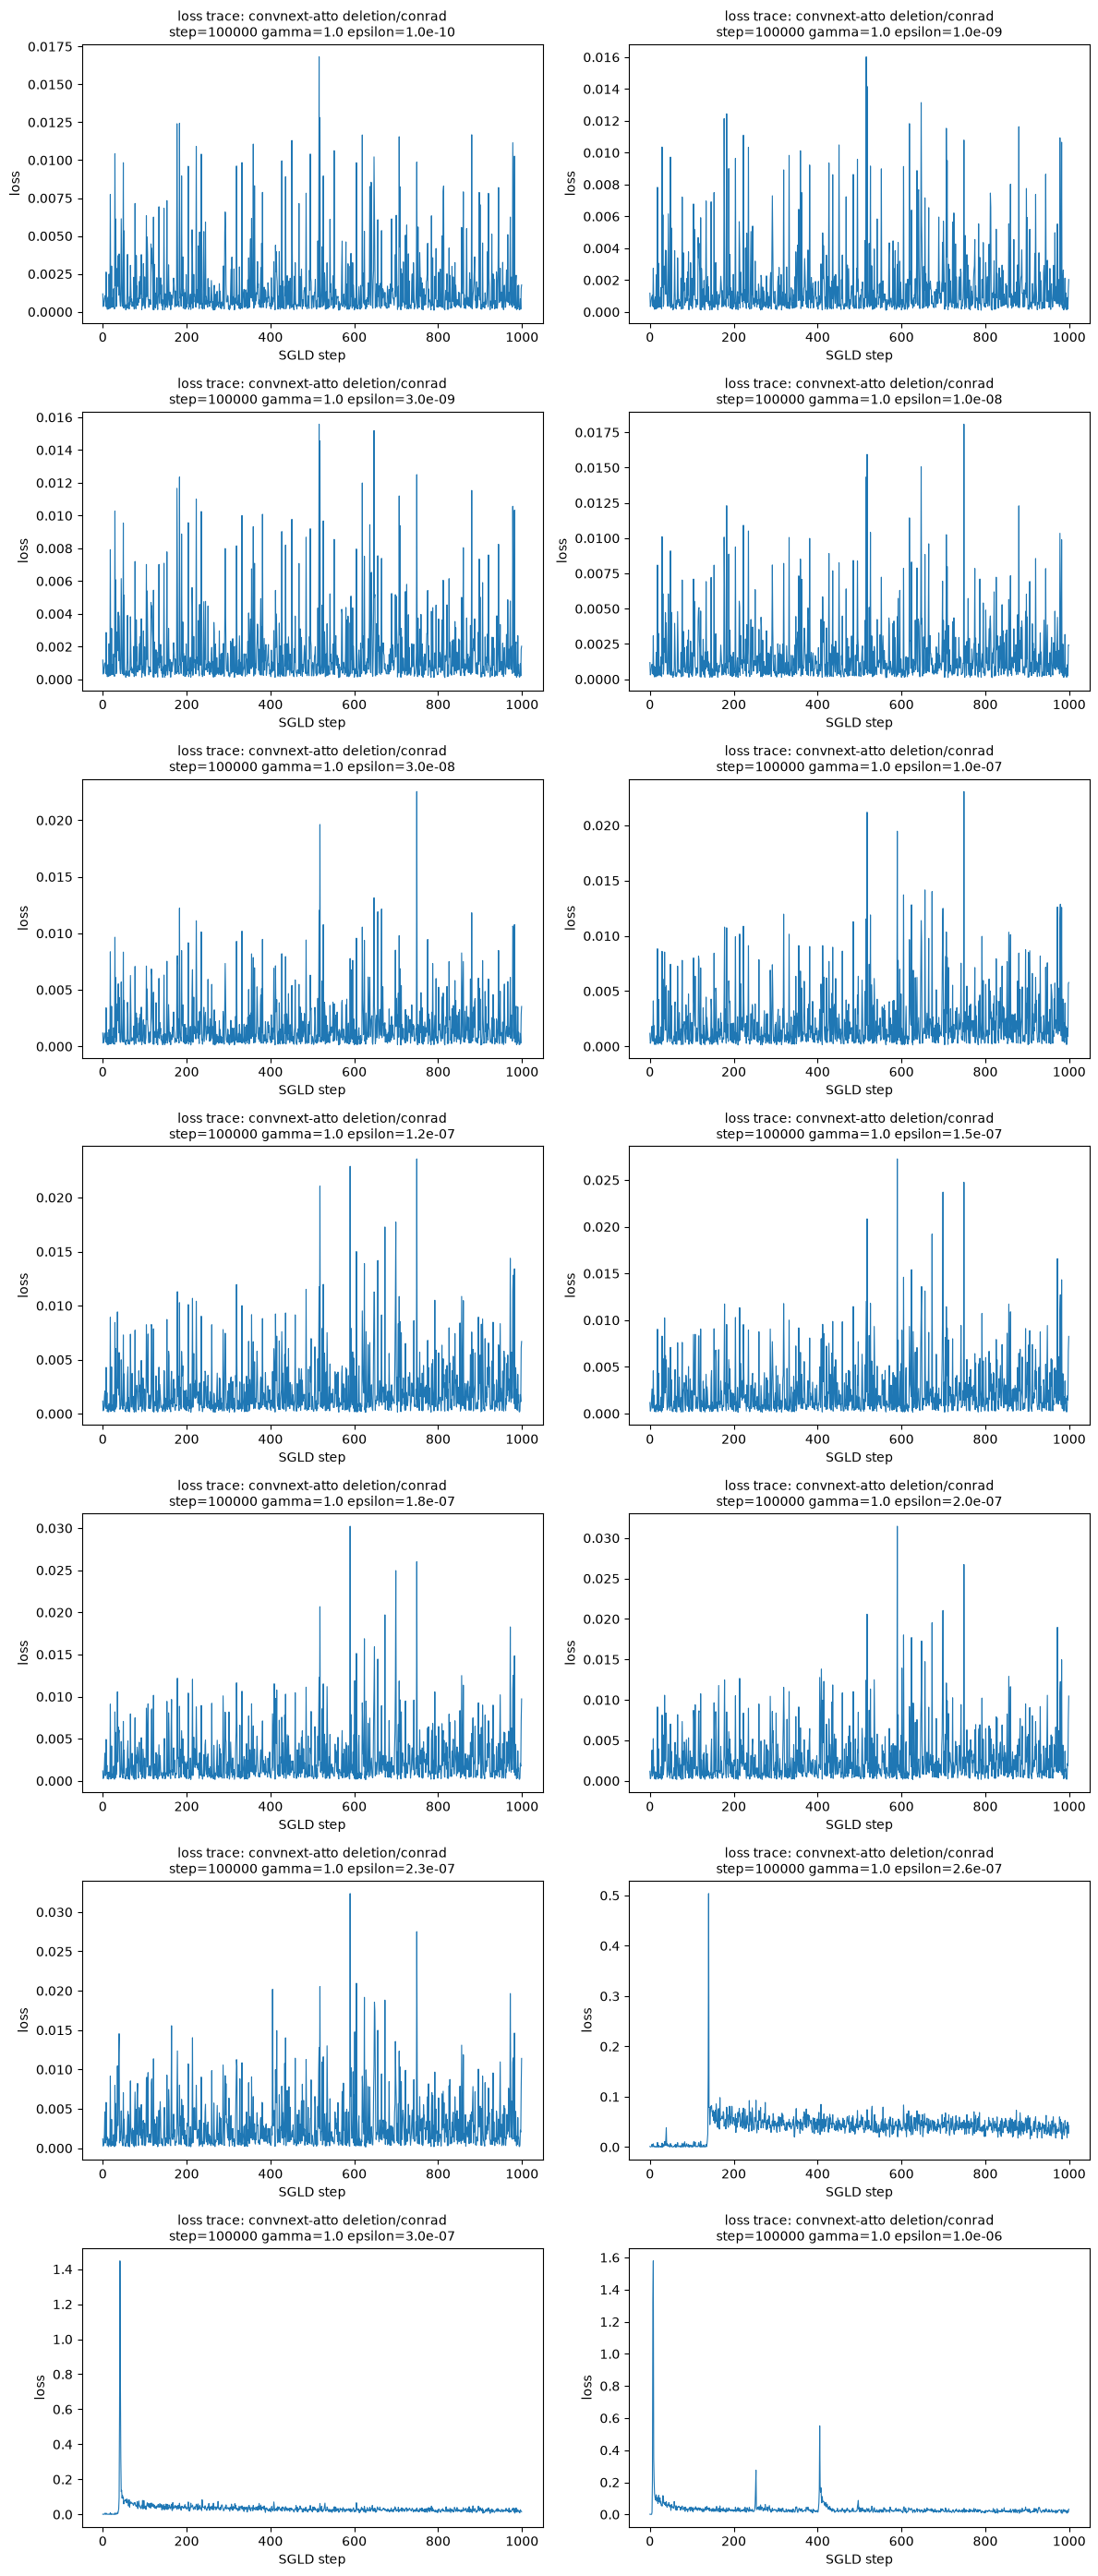

In [2]:
# 個別に欲しい場合
'''
import matplotlib.pyplot as plt

for r in records:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(r["loss_trace"], linewidth=0.8)
    ax.set_xlabel("SGLD step")
    ax.set_ylabel("loss")
    ax.set_title(
        f"loss trace: {r['net']} {r['data_family']}/{r['data_method']} "
        f"step={r['step']} gamma={r['gamma']} epsilon={r['epsilon']:.1e}"
    )
    plt.tight_layout()
    plt.show()
'''   
    
import math
import matplotlib.pyplot as plt

# --- 1. グリッドの列数と行数を決める ---
ncols = 2  # ここを 3 や 4 に変えると横に並ぶ数が増えます
nrows = math.ceil(len(records) / ncols)

# --- 2. 1つの大きなFigureと、複数のAxes（グラフ枠）の配列を作成 ---
# figsizeは列数・行数に合わせて全体のサイズを調整します
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))

# axes が1つの場合や1次元配列になる場合のエラーを防ぐため、1次元リストに平坦化
if nrows * ncols == 1:
    axes_flat = [axes]
else:
    axes_flat = axes.flatten()

# --- 3. ループで順番にグラフを描画 ---
for i, r in enumerate(records):
    ax = axes_flat[i]
    ax.plot(r["loss_trace"], linewidth=0.8)
    ax.set_xlabel("SGLD step")
    ax.set_ylabel("loss")
    
    # タイトルが長いと隣と重なりやすいため、改行(\n)を入れたりフォントサイズを調整しています
    ax.set_title(
        f"loss trace: {r['net']} {r['data_family']}/{r['data_method']}\n"
        f"step={r['step']} gamma={r['gamma']} epsilon={r['epsilon']:.1e}",
        fontsize=10
    )

# --- 4. データ数が枠数に満たない場合、余った空のグラフ枠を非表示にする ---
for j in range(len(records), len(axes_flat)):
    fig.delaxes(axes_flat[j])

# 全体のレイアウトを自動調整して表示
plt.tight_layout()
plt.show()

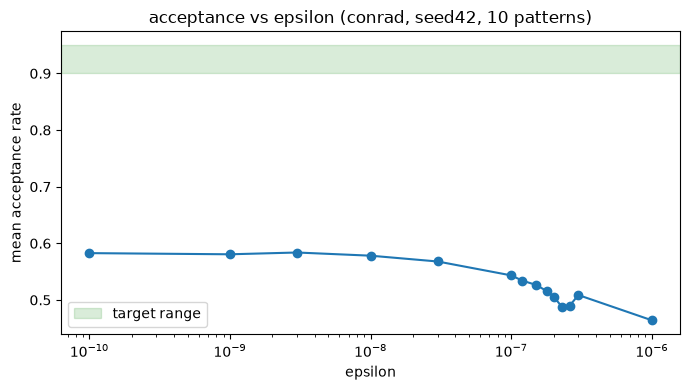

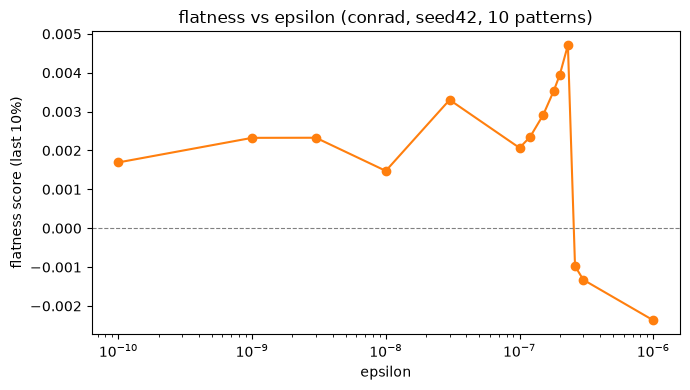

In [3]:
import json
import pandas as pd
from pathlib import Path

CALIB_PATH = Path(
    "/home/nakano/server/calibration_results_deletion_vision/"
    "calib_convnext-atto_deletion_conrad_step100000.json"
)

with open(CALIB_PATH) as f:
    data = json.load(f)

rows = []
for r in data["records"]:
    rows.append({
        "epsilon": r["epsilon"],
        "gamma": r["gamma"],
        "accept": r["mean_accept_prob_full"],
        "flat": r["flatness_score_last10pct"],
        "dist_final": r.get("weight_distance_final", None),
        "llc_mean": r["llc_mean_devinterp_full_avg"],
    })

df_calib = pd.DataFrame(rows).sort_values("epsilon").reset_index(drop=True)
df_calib

import matplotlib.pyplot as plt



fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_calib["epsilon"], df_calib["accept"], marker="o")
ax.axhspan(0.9, 0.95, color="green", alpha=0.15, label="target range")
ax.set_xscale("log")
ax.set_xlabel("epsilon")
ax.set_ylabel("mean acceptance rate")
ax.set_title("acceptance vs epsilon (conrad, seed42, 10 patterns)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_calib["epsilon"], df_calib["flat"], marker="o", color="tab:orange")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xscale("log")
ax.set_xlabel("epsilon")
ax.set_ylabel("flatness score (last 10%)")
ax.set_title("flatness vs epsilon (conrad, seed42, 10 patterns)")
plt.tight_layout()
plt.show()

In [4]:
boundary_epsilons = [1.2e-7, 1.5e-7, 1.8e-7, 2.0e-7, 2.3e-7, 2.6e-7]

with open(main_path) as f:
    data = json.load(f)

boundary_records = sorted(
    [r for r in data["records"] if r["epsilon"] in boundary_epsilons],
    key=lambda r: r["epsilon"],
)
print(f"{len(boundary_records)} boundary records found")
for r in boundary_records:
    print(f"  epsilon={r['epsilon']:.2e}  accept={r['mean_accept_prob_full']:.3f}  "
          f"dist_final={r.get('weight_distance_final', 'N/A')}")


import matplotlib.pyplot as plt
import math

# --- 1. グリッドの列数と行数を決める ---
ncols = 2  # ここを 3 や 4 に変えると横に並ぶ数が増えます
nrows = math.ceil(len(boundary_records) / ncols)

# --- 2. 1つの大きなFigureと、複数のAxes（グラフ枠）の配列を作成 ---
# figsizeは列数・行数に合わせて全体のサイズを調整します
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))

# axes が1つの場合や1次元配列になる場合のエラーを防ぐため、1次元リストに平坦化
if nrows * ncols == 1:
    axes_flat = [axes]
else:
    axes_flat = axes.flatten()

# --- 3. ループで順番にグラフを描画 ---
for i, r in enumerate(boundary_records):
    ax = axes_flat[i]
    ax.plot(r["loss_trace"], linewidth=0.8)
    ax.set_xlabel("SGLD step")
    ax.set_ylabel("loss")

    # タイトルが長いと隣と重なりやすいため、改行(\n)を入れたりフォントサイズを調整しています
    ax.set_title(
        f"loss trace: {r['net']} {r['data_family']}/{r['data_method']}\n"
        f"step={r['step']} gamma={r['gamma']} epsilon={r['epsilon']:.1e}",
        fontsize=10
    )

# --- 4. データ数が枠数に満たない場合、余った空のグラフ枠を非表示にする ---
for j in range(len(boundary_records), len(axes_flat)):
    fig.delaxes(axes_flat[j])

# 全体のレイアウトを自動調整して表示
plt.tight_layout()
plt.show()


NameError: name 'main_path' is not defined

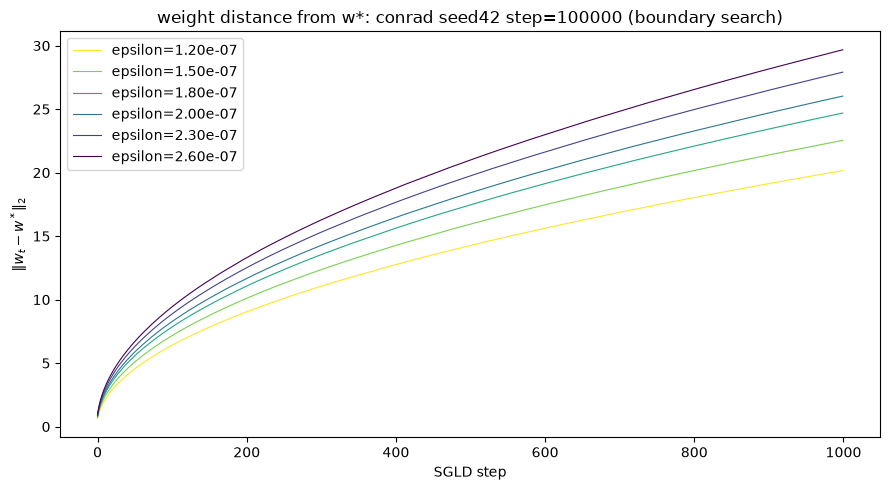

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis_r([i / (len(boundary_records) - 1) for i in range(len(boundary_records))])

for r, c in zip(boundary_records, colors):
    ax.plot(r["weight_distance_trace"], linewidth=0.8, color=c,
            label=f"epsilon={r['epsilon']:.2e}")

ax.set_xlabel("SGLD step")
ax.set_ylabel(r"$\|w_t - w^*\|_2$")
ax.set_title("weight distance from w*: conrad seed42 step=100000 (boundary search)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
epsilon = 2e-7
target_tau = 3000  # このステップ数以内に緩和させたい
required_gamma = 1 / (epsilon * target_tau)
print(f"epsilon={epsilon:.1e} で緩和時間を{target_tau}ステップ以内にするには、gamma >= {required_gamma:.1f} が必要")

epsilon=2.0e-07 で緩和時間を3000ステップ以内にするには、gamma >= 1666.7 が必要


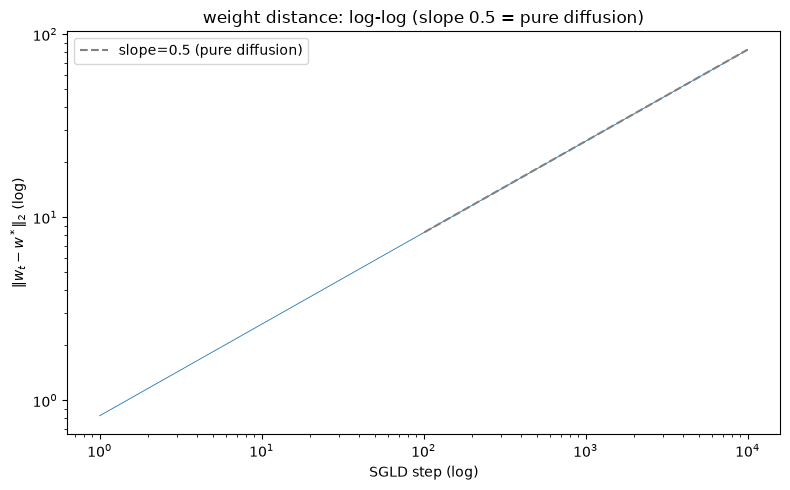

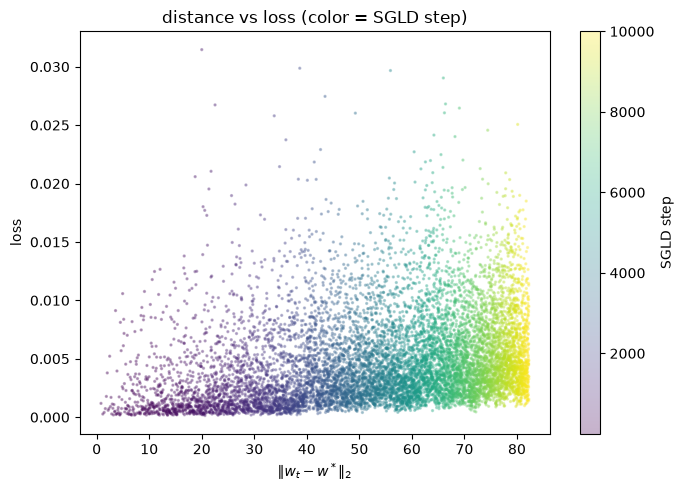

In [ ]:
import numpy as np

dist = np.array(r["weight_distance_trace"])
steps = np.arange(1, len(dist) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, dist, linewidth=0.6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("SGLD step (log)")
ax.set_ylabel(r"$\|w_t - w^*\|_2$ (log)")
ax.set_title("weight distance: log-log (slope 0.5 = pure diffusion)")

# 参考: 傾き0.5の直線を重ねる
ref_x = steps[100:]
ref_y = dist[100] * (ref_x / steps[100]) ** 0.5
ax.plot(ref_x, ref_y, '--', color='gray', label='slope=0.5 (pure diffusion)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(r["weight_distance_trace"], r["loss_trace"], s=2, alpha=0.3, c=steps, cmap="viridis")
ax.set_xlabel(r"$\|w_t - w^*\|_2$")
ax.set_ylabel("loss")
ax.set_title("distance vs loss (color = SGLD step)")
plt.colorbar(sc, label="SGLD step")
plt.tight_layout()
plt.show()

In [9]:
import json
from pathlib import Path

OUT_DIR = Path("/home/nakano/server/calibration_results_deletion_vision_resnet_setting")
METHODS = ["conrad", "gaussian", "ics", "truncated_normal"]

records = {}
for method in METHODS:
    f = OUT_DIR / f"calib_convnext-atto_deletion_{method}_step62000.json"
    if not f.exists():
        print(f"{method}: NOT FOUND ({f})")
        continue
    with open(f) as fh:
        data = json.load(fh)
    recs = [r for r in data["records"] if abs(r["epsilon"] - 2e-7) < 1e-9 and r["total_steps"] == 8000]
    if not recs:
        print(f"{method}: file exists but no matching record")
        continue
    r = recs[0]
    records[method] = r
    print(f"{method:20s} accept_mb={r['mean_accept_prob_full']:.3f}  "
          f"accept_fb={r.get('fixed_batch_mala_accept_mean', 'N/A')}  "
          f"flat={r['flatness_score_last10pct']:.5f}  "
          f"dist_final={r.get('weight_distance_final', 'N/A')}  "
          f"llc={r['llc_mean_devinterp_full_avg']:.3f}")

conrad               accept_mb=0.525  accept_fb=0.5892132644684367  flat=0.00026  dist_final=73.61174011230469  llc=-22.931
gaussian             accept_mb=0.514  accept_fb=0.5223066506849646  flat=0.00018  dist_final=73.6030502319336  llc=107.762
ics                  accept_mb=0.642  accept_fb=0.7648082244451809  flat=-0.00100  dist_final=73.61265563964844  llc=2.947
truncated_normal     accept_mb=0.508  accept_fb=0.5186796643164676  flat=0.00016  dist_final=73.60307312011719  llc=102.712


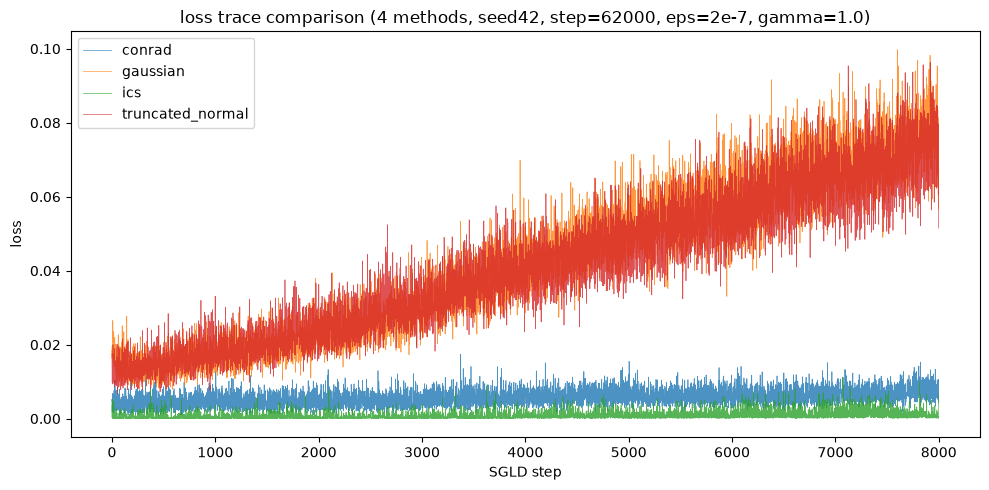

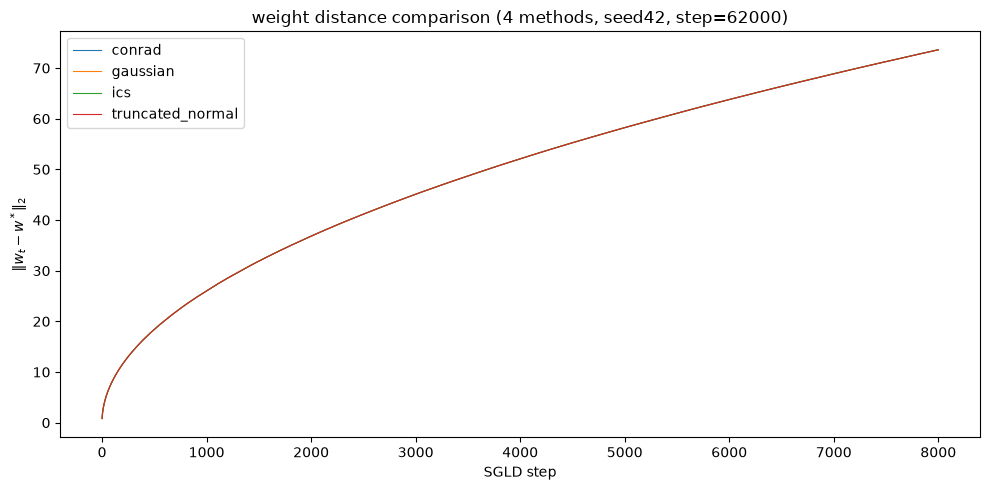

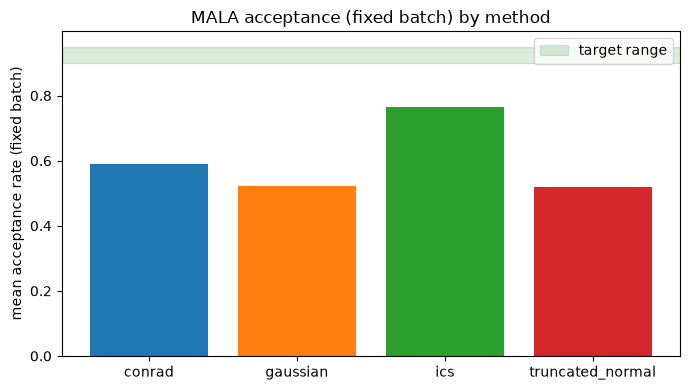

In [14]:
import matplotlib.pyplot as plt

colors = {"conrad": "tab:blue", "gaussian": "tab:orange",
          "ics": "tab:green", "truncated_normal": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 5))
for method, r in records.items():
    ax.plot(r["loss_trace"], linewidth=0.5, label=method, color=colors[method], alpha=0.8)
ax.set_xlabel("SGLD step")
ax.set_ylabel("loss")
ax.set_title("loss trace comparison (4 methods, seed42, step=62000, eps=2e-7, gamma=1.0)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for method, r in records.items():
    if "weight_distance_trace" not in r:
        continue
    ax.plot(r["weight_distance_trace"], linewidth=0.8, label=method, color=colors[method])
ax.set_xlabel("SGLD step")
ax.set_ylabel(r"$\|w_t - w^*\|_2$")
ax.set_title("weight distance comparison (4 methods, seed42, step=62000)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
accepts_fb = [records[m]["fixed_batch_mala_accept_mean"] for m in methods_list]
ax.bar(methods_list, accepts_fb, color=[colors[m] for m in methods_list])
ax.axhspan(0.9, 0.95, color="green", alpha=0.15, label="target range")
ax.set_ylabel("mean acceptance rate (fixed batch)")
ax.set_title("MALA acceptance (fixed batch) by method")
ax.legend()
plt.tight_layout()
plt.show()

conrad               ['8.85', '10.67', '11.90', '12.22']
gaussian             ['109.07', '146.71', '173.29', '181.91']
ics                  ['-7.54', '-7.08', '-6.56', '-6.38']
truncated_normal     ['129.97', '164.49', '186.92', '193.92']


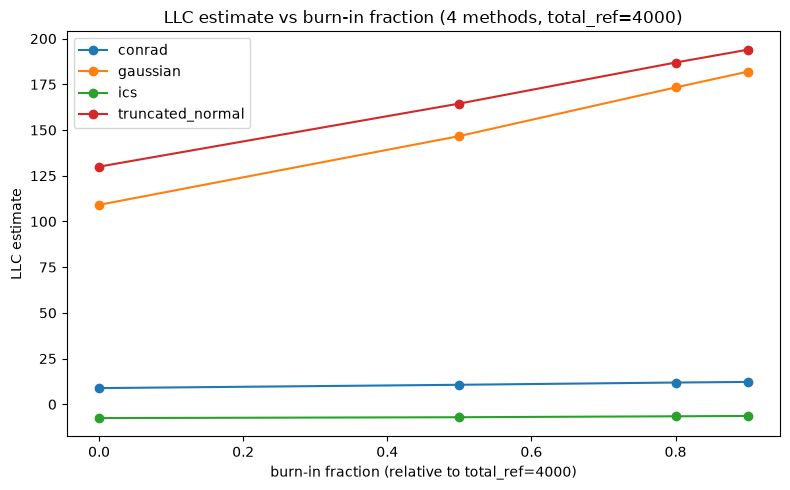

In [18]:
import numpy as np

def compute_llc_from_trace(loss_trace, l_w_star, nbeta,
                             burn_in_frac=0.0, burn_in_steps=None, total_ref=None):
    """
    burn_in_steps: 直接、切り捨てるステップ数を指定 (最優先)
    total_ref: burn_in_frac の基準にするステップ数
               (Noneならトレース自体の長さ len(loss_trace) を基準にする)
               例: total_ref=3000, burn_in_frac=0.9 なら n_burn=2700
    """
    loss_trace = np.array(loss_trace)
    if burn_in_steps is not None:
        n_burn = burn_in_steps
    else:
        base = total_ref if total_ref is not None else len(loss_trace)
        n_burn = int(base * burn_in_frac)
    n_burn = min(n_burn, len(loss_trace) - 1)  # 全部切り捨てないようガード
    tail = loss_trace[n_burn:]
    return nbeta * (np.mean(tail) - l_w_star)

burn_in_fracs = [0.0, 0.5, 0.8, 0.9]
total_ref = 4000  # ← ここを変えれば基準ステップ数を変更できる

llc_by_burnin = {method: [] for method in records}

for method, r in records.items():
    l_w_star_approx = np.mean(r["loss_trace"][:5])
    nbeta = r["nbeta"]
    for frac in burn_in_fracs:
        llc = compute_llc_from_trace(
            r["loss_trace"], l_w_star_approx, nbeta,
            burn_in_frac=frac, total_ref=total_ref)
        llc_by_burnin[method].append(llc)

for method in records:
    print(f"{method:20s}", [f"{v:.2f}" for v in llc_by_burnin[method]])
    
    
fig, ax = plt.subplots(figsize=(8, 5))
for method in records:
    ax.plot(burn_in_fracs, llc_by_burnin[method], marker="o", label=method, color=colors[method])
ax.set_xlabel(f"burn-in fraction (relative to total_ref={total_ref})")
ax.set_ylabel("LLC estimate")
ax.set_title(f"LLC estimate vs burn-in fraction (4 methods, total_ref={total_ref})")
ax.legend()
plt.tight_layout()
plt.show()

# モーメント編集データで学習したモデルの評価（正解率）

In [5]:
import json
import pandas as pd

records = []
for fname in [
    "/home/nakano/server/llc_results_dense/deletion_vision_full_curve_gpu2.jsonl",
    "/home/nakano/server/llc_results_dense/deletion_vision_full_curve_gpu3.jsonl",
]:
    with open(fname) as f:
        for line in f:
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(df.shape)
df.groupby("method")["step"].count()

(6000, 7)


method
conrad              1500
gaussian            1500
ics                 1500
truncated_normal    1500
Name: step, dtype: int64

In [6]:
METHODS = ["conrad", "gaussian", "ics", "truncated_normal"]
metrics = ["train_acc", "train_loss", "test_acc", "test_loss"]

summary = df.groupby(["method", "step"])[metrics].agg(["mean", "std"])
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reset_index()
summary.head()
import matplotlib.pyplot as plt

colors = plt.cm.tab10.colors

def plot_metric(metric_name, ylabel, title, save_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, method in enumerate(METHODS):
        sub = summary[summary["method"] == method].sort_values("step")
        ax.plot(sub["step"], sub[f"{metric_name}_mean"], label=method, color=colors[i])
        ax.fill_between(
            sub["step"],
            sub[f"{metric_name}_mean"] - sub[f"{metric_name}_std"],
            sub[f"{metric_name}_mean"] + sub[f"{metric_name}_std"],
            color=colors[i], alpha=0.2,
        )
    ax.set_xlabel("training step")
    #ax.set_xscale("log")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"/home/nakano/server/llc_results_dense/{save_name}.png", dpi=150)
    plt.show()

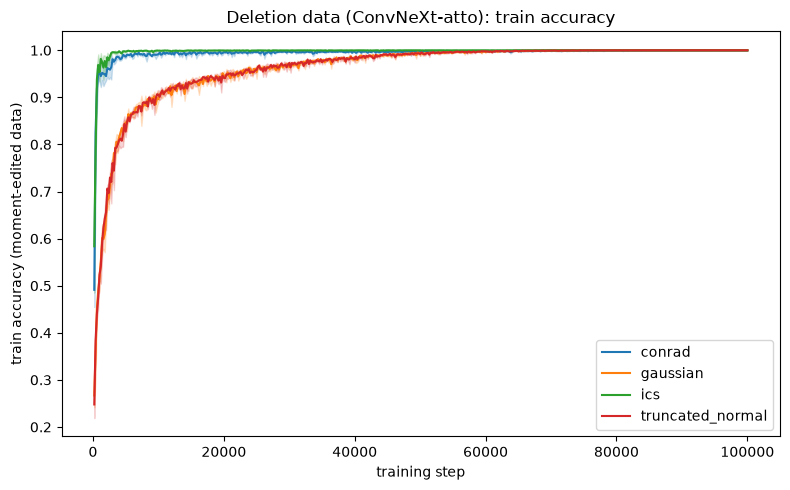

In [7]:
plot_metric("train_acc", "train accuracy (moment-edited data)",
            "Deletion data (ConvNeXt-atto): train accuracy",
            "deletion_vision_train_acc")

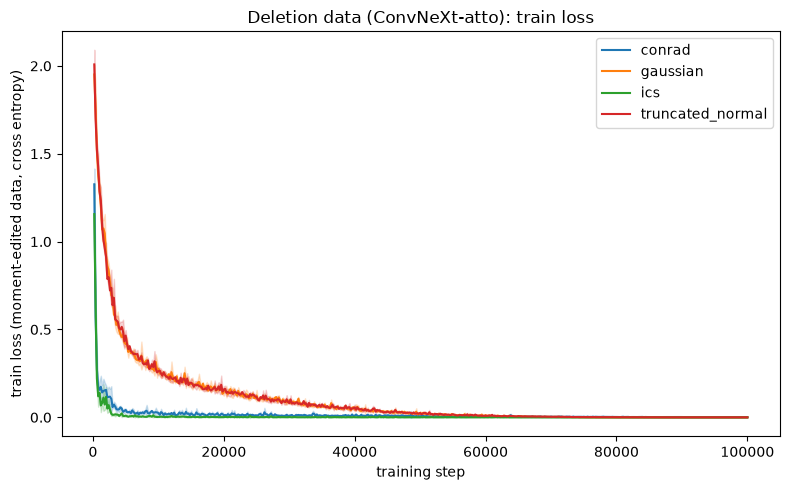

In [8]:
plot_metric("train_loss", "train loss (moment-edited data, cross entropy)",
            "Deletion data (ConvNeXt-atto): train loss",
            "deletion_vision_train_loss")

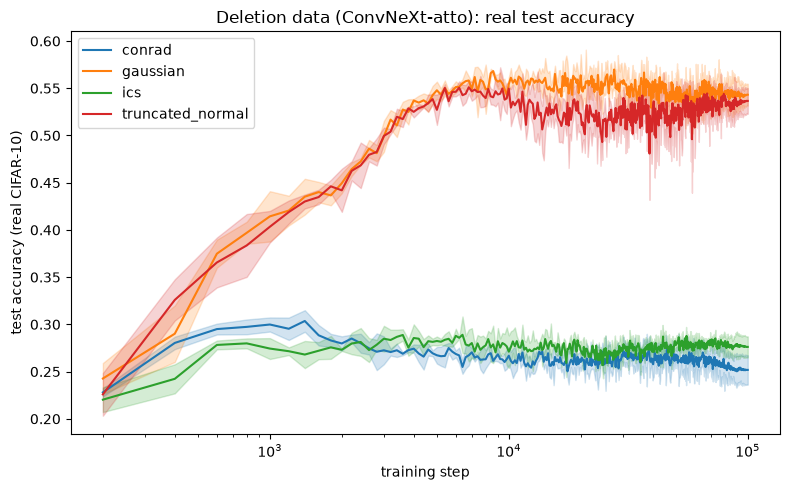

In [ ]:
plot_metric("test_acc", "test accuracy (real CIFAR-10)",
            "Deletion data (ConvNeXt-atto): real test accuracy",
            "deletion_vision_test_acc")

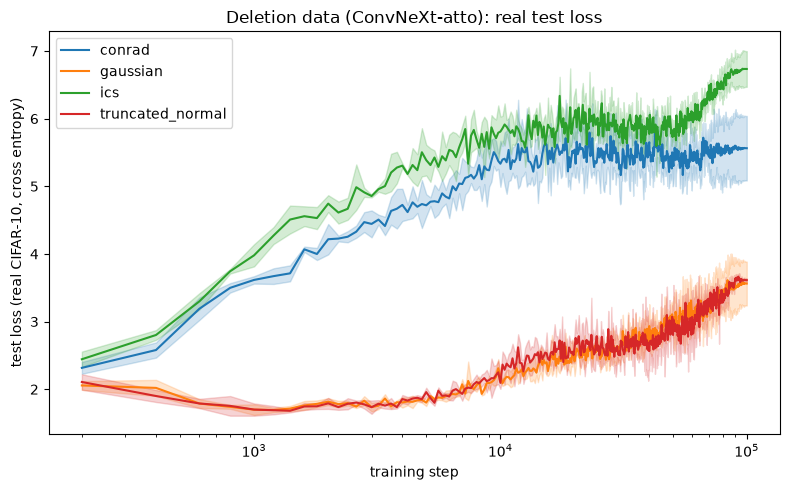

In [ ]:
plot_metric("test_loss", "test loss (real CIFAR-10, cross entropy)",
            "Deletion data (ConvNeXt-atto): real test loss",
            "deletion_vision_test_loss")